In [1]:
# --------------------------------------------------------------
# 🔹 STEP 1: Import Required Libraries
# --------------------------------------------------------------
import os
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [2]:
# --------------------------------------------------------------
# 🔹 STEP 2: Define Dataset Path and Labels
# --------------------------------------------------------------
dataset_path = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT"
categories = ["benign", "malignant", "normal"]

In [3]:
# --------------------------------------------------------------
# 🔹 STEP 3: Load Images and Prepare Data
# --------------------------------------------------------------
IMG_SIZE = (128, 128)
data = []
labels = []

for idx, category in enumerate(categories):
    folder_path = os.path.join(dataset_path, category)
    for file in os.listdir(folder_path):
        if file.endswith(".png"):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            data.append(img.flatten())
            labels.append(idx)

data = np.array(data)
labels = np.array(labels)

print(f"✅ Loaded {len(data)} images successfully!")

✅ Loaded 2531 images successfully!


In [4]:
# --------------------------------------------------------------
# 🔹 STEP 4: Normalize & Split the Data
# --------------------------------------------------------------
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 2024, Testing samples: 507


In [5]:
# --------------------------------------------------------------
# 🔹 STEP 5: Train Random Forest Classifier
# --------------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
print("🎯 Random Forest Model Trained Successfully!")

🎯 Random Forest Model Trained Successfully!


In [6]:
# --------------------------------------------------------------
# 🔹 STEP 6: Evaluate Model
# --------------------------------------------------------------
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy * 100:.2f}%\n")

# Classification Report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=categories))


✅ Model Accuracy: 86.79%

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.91      0.72      0.81       178
   malignant       0.85      0.91      0.88       169
      normal       0.85      0.98      0.91       160

    accuracy                           0.87       507
   macro avg       0.87      0.87      0.87       507
weighted avg       0.87      0.87      0.86       507



c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


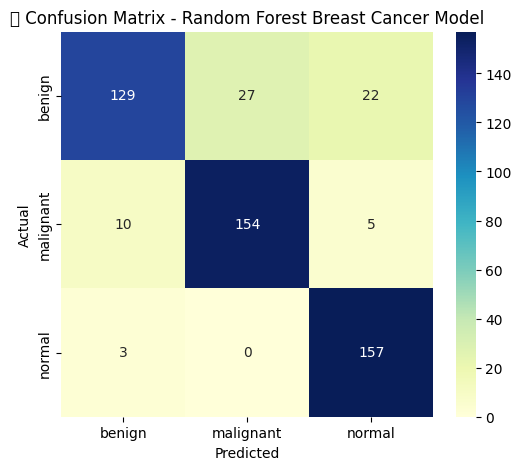

In [7]:
# --------------------------------------------------------------
# 🔹 STEP 7: Confusion Matrix Heatmap
# --------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("🔍 Confusion Matrix - Random Forest Breast Cancer Model")
plt.show()

In [8]:
# --------------------------------------------------------------
# 🔹 STEP 8: Save Model & Scaler
# --------------------------------------------------------------
os.makedirs("model", exist_ok=True)
joblib.dump(rf_model, "model/random_forest_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
print("💾 Model and Scaler saved successfully in 'model' folder!")

💾 Model and Scaler saved successfully in 'model' folder!



🎯 Prediction Result
---------------------------
Predicted Class: Malignant
Confidence: 78.97%
---------------------------


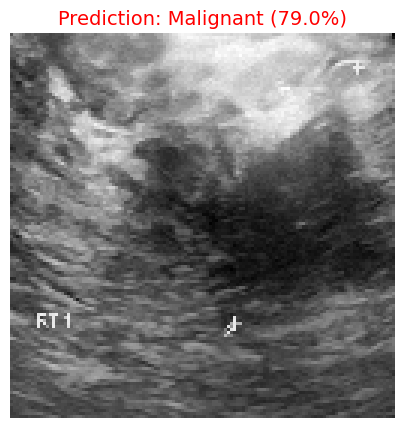

In [10]:
# --------------------------------------------------------------
# 🔹 STEP 9: Predict a Specific Image (User Input)
# --------------------------------------------------------------
image_path = input("📸 Enter full path of the image to predict: ").strip()

if not os.path.exists(image_path):
    raise FileNotFoundError(f"❌ Image not found at: {image_path}")

# Load the model and scaler
rf_model = joblib.load("model/random_forest_model.pkl")
scaler = joblib.load("model/scaler.pkl")

# Read and preprocess image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("⚠️ Could not read the image file.")
img_resized = cv2.resize(img, IMG_SIZE)
img_flatten = img_resized.flatten().reshape(1, -1)
img_scaled = scaler.transform(img_flatten)

# Predict
pred = rf_model.predict(img_scaled)[0]
confidence = rf_model.predict_proba(img_scaled).max() * 100

# Map labels
label_map = {0: "Benign", 1: "Malignant", 2: "Normal"}
pred_label = label_map[pred]

# Show results
print("\n🎯 Prediction Result")
print("---------------------------")
print("Predicted Class:", pred_label)
print(f"Confidence: {confidence:.2f}%")
print("---------------------------")

# Display image with prediction
plt.figure(figsize=(5,5))
plt.imshow(img_resized, cmap='gray')
title_color = 'green' if pred_label.lower() == 'normal' else ('red' if pred_label.lower() == 'malignant' else 'blue')
plt.title(f"Prediction: {pred_label} ({confidence:.1f}%)", color=title_color, fontsize=14)
plt.axis('off')
plt.show()

In [11]:
# --------------------------------------------------------------
# 🔹 Check Accuracy of Random Forest Model
# --------------------------------------------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict the test data
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy * 100:.2f}%")

# Print classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=categories))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n🧩 Confusion Matrix:")
print(cm)


✅ Model Accuracy: 86.79%

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.91      0.72      0.81       178
   malignant       0.85      0.91      0.88       169
      normal       0.85      0.98      0.91       160

    accuracy                           0.87       507
   macro avg       0.87      0.87      0.87       507
weighted avg       0.87      0.87      0.86       507


🧩 Confusion Matrix:
[[129  27  22]
 [ 10 154   5]
 [  3   0 157]]
